In [1]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [2]:
# load data using functions coded in load_mnist.py
X_train = load_mnist.load_images(load_mnist.f_training_images)/255.0
y_train = load_mnist.load_labels(load_mnist.f_training_labels)

X_test = load_mnist.load_images(load_mnist.f_test_images)/255.0
y_test = load_mnist.load_labels(load_mnist.f_test_labels)

# investigate potential for a low-rank decomposition

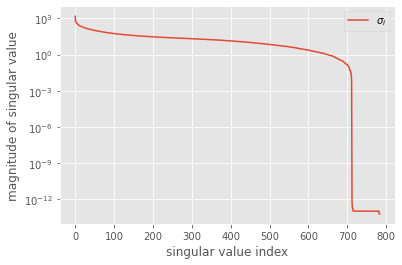

In [54]:
U, S, VT = np.linalg.svd(X_train, full_matrices=False)

plt.plot(range(len(S)),S, label=r'$\sigma_i$')
plt.semilogy()
plt.xlabel('singular value index')
plt.ylabel('magnitude of singular value')
plt.legend()

In [13]:
def train_lowrank_classifier(U, S, VT, y, r, lam):
    """truncated SVD classifier for a match with the supplied digit
    the basic formula is w=(X.T@X)^(-1)X^Ty, but we create y as a membership matrix    
    """
    
    # create a matrix for y, where columns yj contain a 1 if yi=j, -1 if yi<>j
    y_mat = load_mnist.digit_2_matrix(y)
       
    # truncate the singular values to rank-r
    V = VT.T[:,:r]
    UT = U.T[:r,:]
    Sr = np.linalg.inv(np.diag(S[:r]))
    
    w = np.zeros((784, 10))
    
    # L2-regularized low-rank approximation
    
    for i in range(r):        
        w += S[i]/(S[i]**2+lam) * np.outer(V[:,i], (UT[i,:]@y_mat))
    
    return w

# Test performance with $50 \leq r \leq 750$

In [45]:
r_arr = np.linspace(50, 750, 10)
lam_arr = np.array([1, 1e1, 1e2, 1e3, 1e4])

err_test = np.zeros((len(r_arr), len(lam_arr)))

# step through rank-r approximations
for i, r in enumerate(r_arr):
                    
    # step through regularizer values
    for j, lam in enumerate(lam_arr):
                    
        w = train_lowrank_classifier(U, S, VT, y_train, int(r), lam)
        
        y_hat = load_mnist.matrix_2_digit(X_test@w)
        err_test[i,j] = 1 - np.sum(np.equal(y_hat, y_test)) / len(y_test)

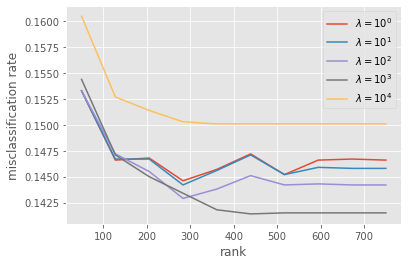

In [46]:
plt.plot(r_arr, err_test[:,0], label=r'$\lambda = 10^{0}$')
plt.plot(r_arr, err_test[:,1], label=r'$\lambda = 10^{1}$')
plt.plot(r_arr, err_test[:,2], label=r'$\lambda = 10^{2}$')
plt.plot(r_arr, err_test[:,3], label=r'$\lambda = 10^{3}$')
plt.plot(r_arr, err_test[:,4], label=r'$\lambda = 10^{4}$')

plt.xlabel('rank')
plt.ylabel('misclassification rate')
plt.legend()

# Explore bias of classifier

In [51]:
# weight matrix m-rows x 10-cols, column represents weights for classifying that digit
w = train_lowrank_classifier(U, S, VT, y_train, 450, 1e3)

# test using test dataset
y_hat = load_mnist.matrix_2_digit(X_test@w)
error_rate = 1-np.sum(np.equal(y_hat, y_test)) / len(y_test)

print('Error rate: {:0.1%}'.format(error_rate))

import pandas as pd

df = pd.DataFrame(data=np.hstack((y_test, np.equal(y_hat,y_test))), columns=['digit', 'correct'])
pt = df.pivot_table(index='digit', values=['correct', 'correct'], aggfunc=[len, np.sum])
pt = pt.stack().reset_index()
pt['error'] = 1-pt['sum']/pt['len']

Error rate: 14.1%


In [52]:
pt

,digit,level_1,len,sum,error
0,0.0,correct,980.0,940.0,0.040816
1,1.0,correct,1135.0,1107.0,0.024670
2,2.0,correct,1032.0,830.0,0.195736
3,3.0,correct,1010.0,886.0,0.122772
4,4.0,correct,982.0,875.0,0.108961
5,5.0,correct,892.0,602.0,0.325112
6,6.0,correct,958.0,888.0,0.073069
7,7.0,correct,1028.0,887.0,0.137160
8,8.0,correct,974.0,748.0,0.232033
9,9.0,correct,1009.0,823.0,0.184341


Text(0, 0.5, 'misclassification rate')

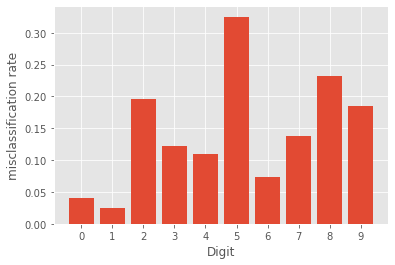

In [53]:
plt.bar(pt['digit'], pt['error'])
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('misclassification rate')